In [1]:
!pip install ultralytics opencv-python matplotlib tqdm scikit-learn

In [2]:
import os
import json
import math
import shutil
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score

In [4]:
BASE_PATH = "data/sign_dataset"
YOLO_PATH = "data/yolo_seg"
CUSTOM_PATH = "my_photos"

In [4]:
shutil.rmtree(YOLO_PATH, ignore_errors=True)

os.makedirs(f"{YOLO_PATH}/images/train", exist_ok=True)
os.makedirs(f"{YOLO_PATH}/images/val", exist_ok=True)
os.makedirs(f"{YOLO_PATH}/labels/train", exist_ok=True)
os.makedirs(f"{YOLO_PATH}/labels/val", exist_ok=True)

In [5]:
for split in ["train", "val"]:
    via_path = os.path.join(BASE_PATH, split, "via_region_data.json")

    with open(via_path, "r", encoding="utf-8") as f:
        via_data = json.load(f)

    for _, item in tqdm(via_data.items(), desc=split):
        filename = item["filename"]
        img_path = os.path.join(BASE_PATH, split, filename)

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        lines = []

        regions = item.get("regions", {})
        if isinstance(regions, list):
            iterable_regions = regions
        else:
            iterable_regions = regions.values()

        for region in iterable_regions:
            region_attrs = region.get("region_attributes", {})
            if region_attrs.get("name") != "road sign":
                continue

            shape = region.get("shape_attributes", {})
            shape_name = shape.get("name")

            pts = []

            if shape_name == "polygon":
                xs = shape.get("all_points_x", [])
                ys = shape.get("all_points_y", [])
                if len(xs) >= 3 and len(xs) == len(ys):
                    for x, y in zip(xs, ys):
                        pts.append([float(x), float(y)])

            elif shape_name == "ellipse":
                cx = float(shape.get("cx", 0))
                cy = float(shape.get("cy", 0))
                rx = float(shape.get("rx", 0))
                ry = float(shape.get("ry", 0))
                for t in np.linspace(0, 2 * math.pi, 24, endpoint=False):
                    x = cx + rx * math.cos(t)
                    y = cy + ry * math.sin(t)
                    pts.append([x, y])

            if len(pts) < 3:
                continue

            coords = []
            for x, y in pts:
                x = min(max(x, 0), w - 1)
                y = min(max(y, 0), h - 1)
                coords.append(f"{x / w:.6f}")
                coords.append(f"{y / h:.6f}")

            lines.append("0 " + " ".join(coords))

        cv2.imwrite(os.path.join(YOLO_PATH, f"images/{split}", filename), img)

        with open(os.path.join(YOLO_PATH, f"labels/{split}", filename.rsplit(".", 1)[0] + ".txt"), "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

val: 100%|██████████| 127/127 [00:01<00:00, 71.58it/s] 


In [6]:
with open("signs.yaml", "w", encoding="utf-8") as f:
    f.write(f"""path: {YOLO_PATH}
train: images/train
val: images/val

names:
  0: road_sign
""")

In [7]:
print("train images:", len(os.listdir(f"{YOLO_PATH}/images/train")))
print("train labels:", len(os.listdir(f"{YOLO_PATH}/labels/train")))
print("val images:", len(os.listdir(f"{YOLO_PATH}/images/val")))
print("val labels:", len(os.listdir(f"{YOLO_PATH}/labels/val")))

train images: 2054
train labels: 2054
val images: 127
val labels: 127


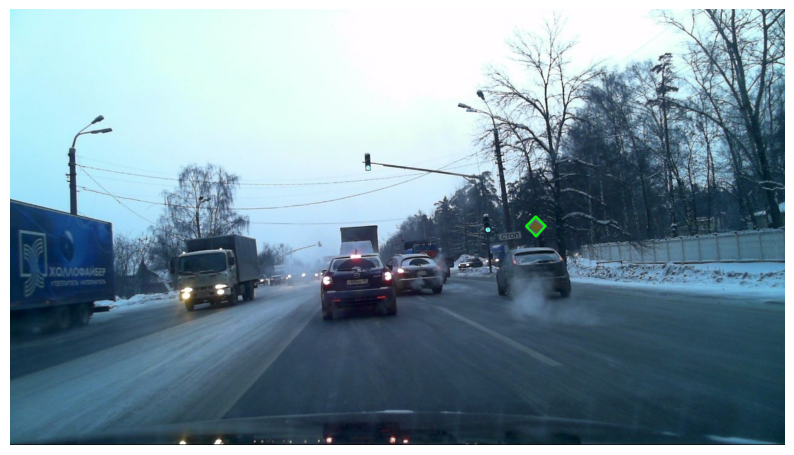

In [8]:
split = "train"
img_dir = os.path.join(YOLO_PATH, f"images/{split}")
lbl_dir = os.path.join(YOLO_PATH, f"labels/{split}")

img_name = random.choice([x for x in os.listdir(img_dir) if x.endswith(".jpg")])
img_path = os.path.join(img_dir, img_name)
lbl_path = os.path.join(lbl_dir, img_name.rsplit(".", 1)[0] + ".txt")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

with open(lbl_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))
        pts = []
        for i in range(0, len(coords), 2):
            pts.append([int(coords[i] * w), int(coords[i + 1] * h)])
        pts = np.array(pts, dtype=np.int32)
        cv2.polylines(img, [pts], True, (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
model = YOLO("yolo11s-seg.pt")

model.train(
    data="signs.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    name="road_signs_seg"
)

New https://pypi.org/project/ultralytics/8.4.35 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=signs.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_si

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021B9B221780>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [6]:
model = YOLO("C:/Users/artem/runs/segment/road_signs_seg4/weights/best.pt")

In [16]:
def build_mask_from_regions(item, shape):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    regions = item.get("regions", {})
    if isinstance(regions, list):
        iterable_regions = regions
    else:
        iterable_regions = regions.values()

    for region in iterable_regions:
        region_attrs = region.get("region_attributes", {})
        if region_attrs.get("name") != "road sign":
            continue

        shape_attrs = region.get("shape_attributes", {})
        shape_name = shape_attrs.get("name")

        if shape_name == "polygon":
            xs = shape_attrs.get("all_points_x", [])
            ys = shape_attrs.get("all_points_y", [])
            if len(xs) >= 3 and len(xs) == len(ys):
                pts = np.array(list(zip(xs, ys)), dtype=np.int32)
                cv2.fillPoly(mask, [pts], 1)

        elif shape_name == "ellipse":
            cx = int(round(shape_attrs.get("cx", 0)))
            cy = int(round(shape_attrs.get("cy", 0)))
            rx = int(round(shape_attrs.get("rx", 0)))
            ry = int(round(shape_attrs.get("ry", 0)))
            if rx > 0 and ry > 0:
                cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 1, -1)

    return mask

In [17]:
def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return 0.0
    return intersection / union

In [18]:
val_json_path = os.path.join(BASE_PATH, "val", "via_region_data.json")
with open(val_json_path, "r", encoding="utf-8") as f:
    val_data = json.load(f)

ious = []
precisions = []
recalls = []
l2_errors = []

for _, item in tqdm(val_data.items(), desc="val metrics"):
    filename = item["filename"]
    img_path = os.path.join(BASE_PATH, "val", filename)

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    gt_mask = build_mask_from_regions(item, img.shape)
    gt_bin = (gt_mask > 0).astype(np.uint8)

    if gt_bin.sum() == 0:
        continue

    result = model(img_path)[0]

    if result.masks is not None and len(result.masks.data) > 0:
        pred_masks = result.masks.data.cpu().numpy()
        pred_union = np.any(pred_masks > 0.5, axis=0).astype(np.uint8)
        pred_bin = cv2.resize(pred_union, (w, h), interpolation=cv2.INTER_NEAREST)
        pred_bin = (pred_bin > 0).astype(np.uint8)
    else:
        pred_bin = np.zeros((h, w), dtype=np.uint8)

    iou = compute_iou(pred_bin, gt_bin)
    ious.append(iou)

    y_true = gt_bin.flatten()
    y_pred = pred_bin.flatten()

    precisions.append(precision_score(y_true, y_pred, zero_division=0))
    recalls.append(recall_score(y_true, y_pred, zero_division=0))

    l2 = np.sqrt(((y_true.astype(np.float32) - y_pred.astype(np.float32)) ** 2).mean())
    l2_errors.append(l2)

print("IoU:", np.mean(ious))
print("Precision:", np.mean(precisions))
print("Recall:", np.mean(recalls))
print("L2:", np.mean(l2_errors))
print("IoU >= 0.5:", np.mean(np.array(ious) >= 0.5))
print("IoU >= 0.75:", np.mean(np.array(ious) >= 0.75))
print("IoU >= 0.9:", np.mean(np.array(ious) >= 0.9))

val metrics:   0%|          | 0/127 [00:00<?, ?it/s]


image 1/1 c:\Users\artem\Downloads\cv lab\data\sign_dataset\val\2176.jpg: 384x640 4 road_signs, 92.0ms
Speed: 3.0ms preprocess, 92.0ms inference, 14.4ms postprocess per image at shape (1, 3, 384, 640)


val metrics:   1%|          | 1/127 [00:00<01:16,  1.65it/s]


image 1/1 c:\Users\artem\Downloads\cv lab\data\sign_dataset\val\2174.jpg: 384x640 3 road_signs, 52.7ms
Speed: 2.5ms preprocess, 52.7ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)


val metrics:   2%|▏         | 2/127 [00:00<00:45,  2.75it/s]

...


image 1/1 c:\Users\artem\Downloads\cv lab\data\sign_dataset\val\214.jpg: 640x480 3 road_signs, 64.3ms
Speed: 4.2ms preprocess, 64.3ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 480)


val metrics:  99%|█████████▉| 126/127 [00:38<00:01,  1.81s/it]


image 1/1 c:\Users\artem\Downloads\cv lab\data\sign_dataset\val\213.jpg: 640x480 4 road_signs, 68.3ms
Speed: 3.9ms preprocess, 68.3ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 480)


val metrics: 100%|██████████| 127/127 [00:40<00:00,  3.14it/s]

IoU: 0.5890722942304372
Precision: 0.6843131527119665
Recall: 0.8179889623041983
L2: 0.054802243
IoU >= 0.5: 0.7952755905511811
IoU >= 0.75: 0.09448818897637795
IoU >= 0.9: 0.0



image 1/1 c:\Users\artem\Downloads\cv lab\data\sign_dataset\val\2164.jpg: 384x640 3 road_signs, 63.5ms
Speed: 2.8ms preprocess, 63.5ms inference, 5.0ms postprocess per image at shape (1, 3, 384, 640)


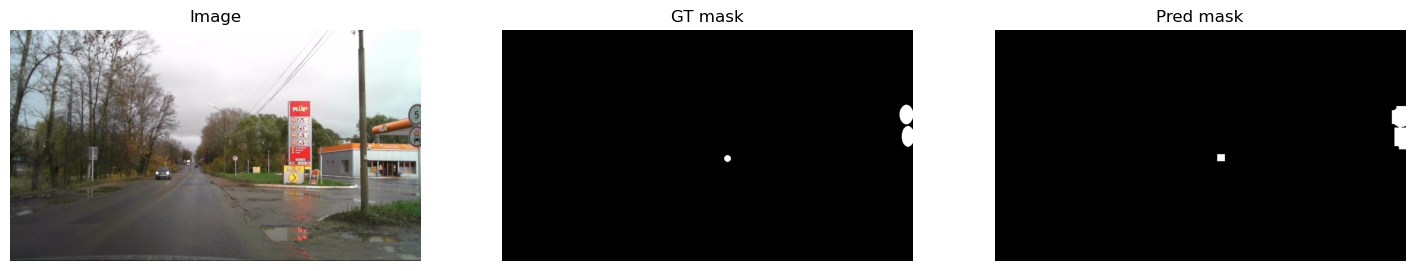

In [19]:
sample_keys = list(val_data.keys())
sample_key = random.choice(sample_keys)
item = val_data[sample_key]
filename = item["filename"]
img_path = os.path.join(BASE_PATH, "val", filename)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

gt_mask = build_mask_from_regions(item, img.shape)

result = model(img_path)[0]

if result.masks is not None and len(result.masks.data) > 0:
    pred_masks = result.masks.data.cpu().numpy()
    pred_union = np.any(pred_masks > 0.5, axis=0).astype(np.uint8)
    pred_mask = cv2.resize(pred_union, (w, h), interpolation=cv2.INTER_NEAREST)
else:
    pred_mask = np.zeros((h, w), dtype=np.uint8)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("GT mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Pred mask")
plt.axis("off")

plt.show()


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\1.jpg: 384x640 2 road_signs, 266.3ms
Speed: 4.0ms preprocess, 266.3ms inference, 61.8ms postprocess per image at shape (1, 3, 384, 640)


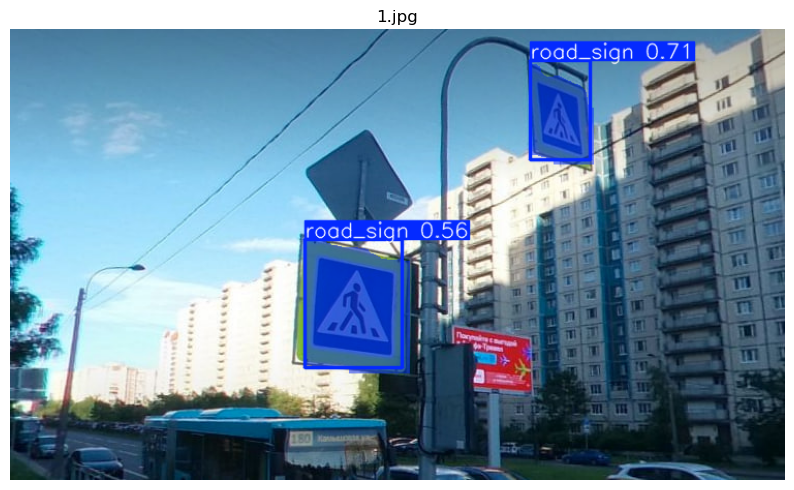


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\10.jpg: 640x480 (no detections), 188.9ms
Speed: 2.8ms preprocess, 188.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


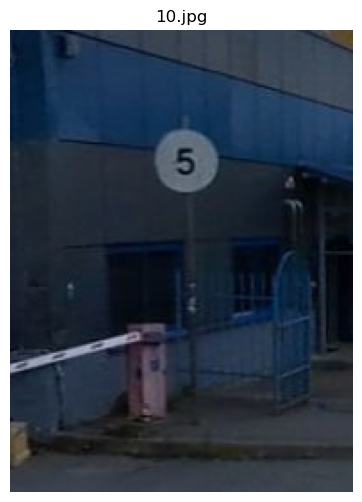


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\11.jpg: 640x384 1 road_sign, 208.3ms
Speed: 2.9ms preprocess, 208.3ms inference, 12.3ms postprocess per image at shape (1, 3, 640, 384)


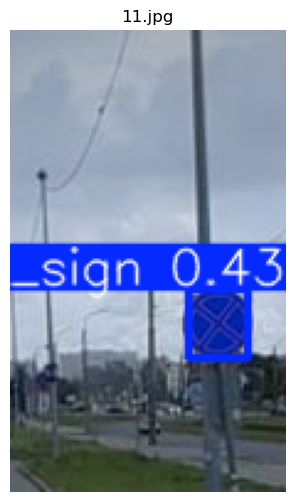


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\2.jpg: 640x416 (no detections), 143.6ms
Speed: 3.1ms preprocess, 143.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 416)


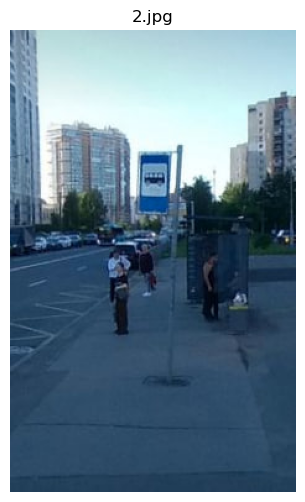


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\3.jpg: 640x384 (no detections), 28.6ms
Speed: 3.3ms preprocess, 28.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)


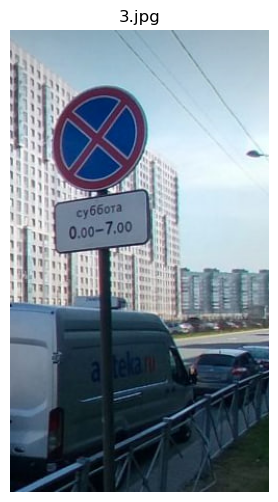


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\4.jpg: 640x416 1 road_sign, 24.1ms
Speed: 1.6ms preprocess, 24.1ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 416)


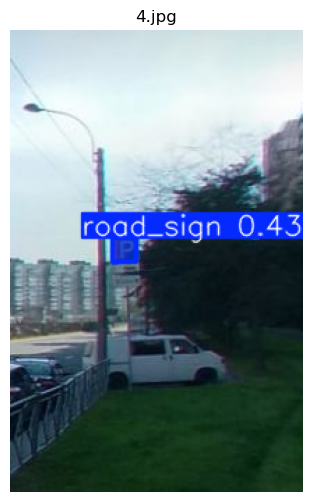


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\5.jpg: 640x416 1 road_sign, 44.3ms
Speed: 3.4ms preprocess, 44.3ms inference, 6.4ms postprocess per image at shape (1, 3, 640, 416)


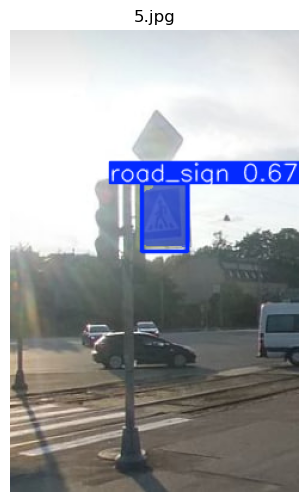


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\6.jpg: 640x480 1 road_sign, 37.0ms
Speed: 3.7ms preprocess, 37.0ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 480)


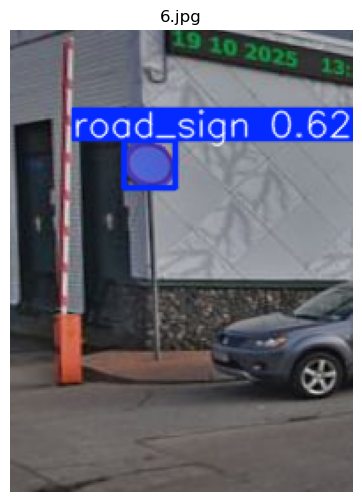


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\7.jpg: 640x416 2 road_signs, 32.7ms
Speed: 4.3ms preprocess, 32.7ms inference, 8.1ms postprocess per image at shape (1, 3, 640, 416)


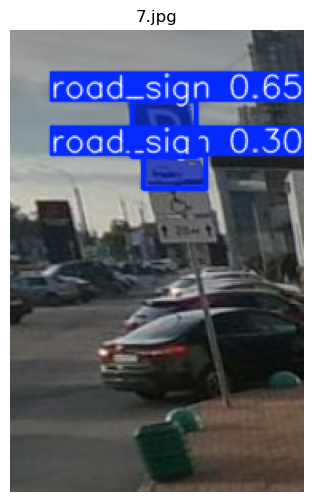


image 1/1 c:\Users\artem\Downloads\cv lab\my_photos\8.jpg: 640x480 1 road_sign, 28.4ms
Speed: 2.6ms preprocess, 28.4ms inference, 5.1ms postprocess per image at shape (1, 3, 640, 480)


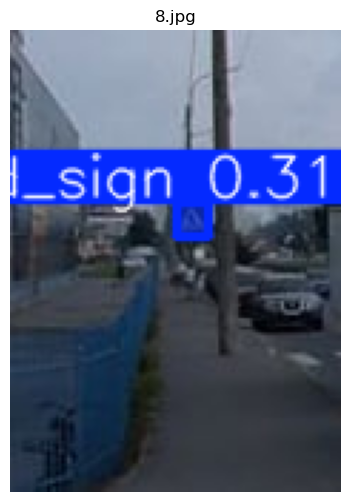

In [7]:
custom_results = []

if os.path.exists(CUSTOM_PATH):
    custom_files = [x for x in os.listdir(CUSTOM_PATH) if x.lower().endswith((".jpg", ".jpeg", ".png"))][:10]

    for filename in custom_files:
        img_path = os.path.join(CUSTOM_PATH, filename)
        result = model(img_path)[0]
        custom_results.append((filename, result))

        plotted = result.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(plotted)
        plt.title(filename)
        plt.axis("off")
        plt.show()
else:
    print("Папка my_photos не найдена")